<a href="https://colab.research.google.com/github/vishalkoshal80-dev/Machine-learning/blob/main/Titanic_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from google.colab import files
uploaded = files.upload()

Saving train_and_test2.csv to train_and_test2.csv


In [11]:
import pandas as pd
df = pd.read_csv("/content/train_and_test2.csv")

In [12]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [13]:
df.tail()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1308,1309,28.0,22.3583,0,1,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0


In [14]:
df.isnull().sum()

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


In [15]:
df[df["Embarked"].isnull()]

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
61,62,38.0,80.0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,NaN,0,0,1
829,830,62.0,80.0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,NaN,0,0,1


In [16]:
df["Embarked"] = df['Embarked'].fillna(df["Embarked"].mode()[0])

In [17]:
df.isnull().sum()

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


In [18]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1304,False
1305,False
1306,False
1307,False


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [21]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1309.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.493506,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814244,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


In [22]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [25]:
df = df.drop(columns=[col for col in df.columns if col.startswith('zero')])

In [26]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [27]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', '2urvived'],
      dtype='object')

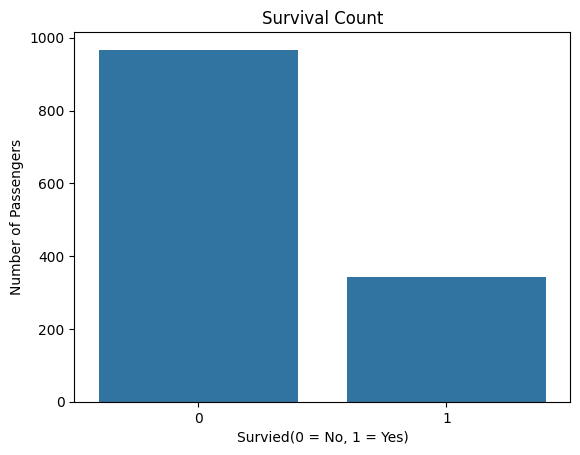

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x = '2urvived', data=df)
plt.title('Survival Count')
plt.xlabel('Survied(0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

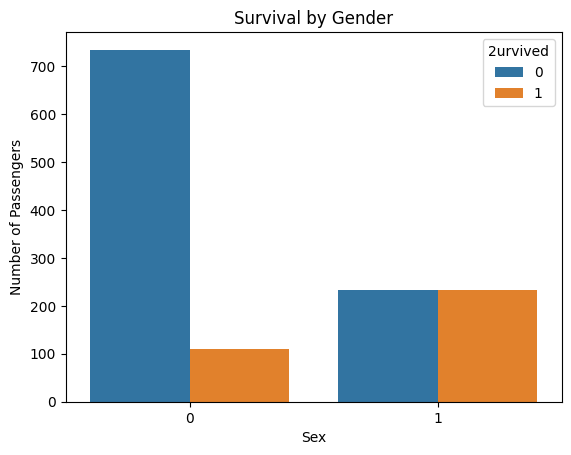

In [33]:
sns.countplot(x='Sex', hue='2urvived', data=df)
plt.title('Survival by Gender')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.show()

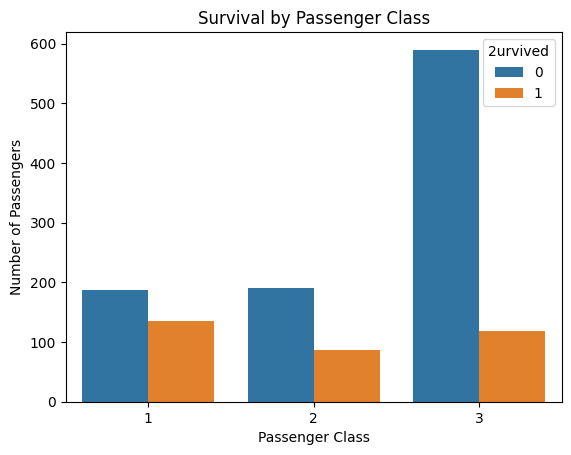

In [34]:
sns.countplot(x='Pclass', hue='2urvived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()


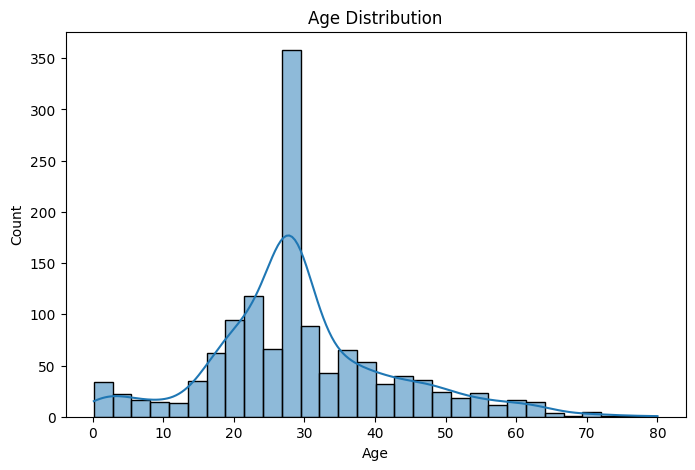

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

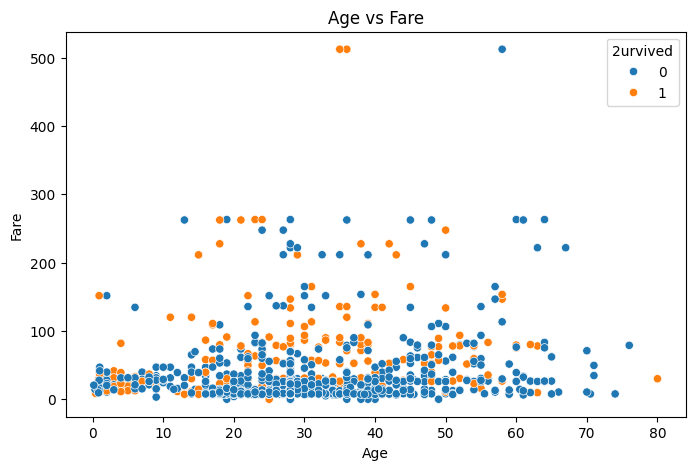

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Fare',
    hue='2urvived',
    data=df
)

plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

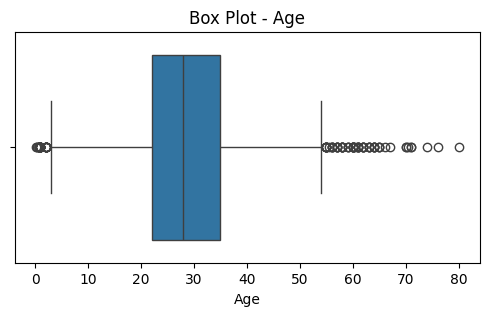

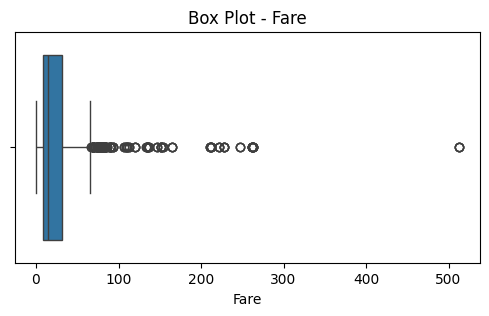

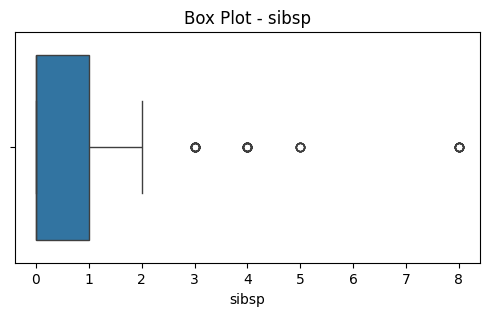

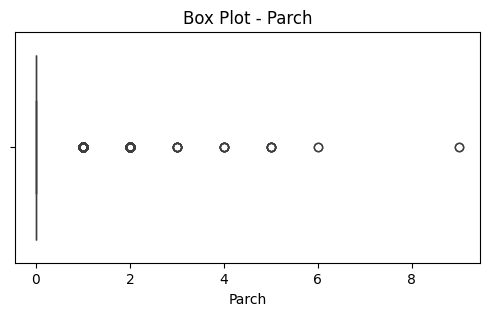

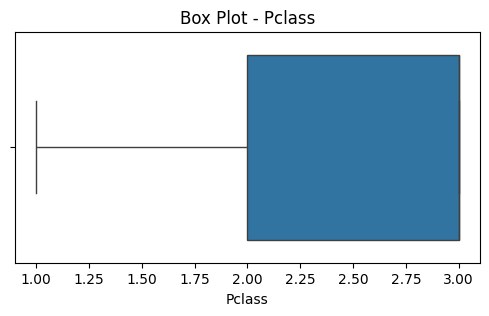

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Age', 'Fare', 'sibsp', 'Parch', 'Pclass']

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot - {col}')
    plt.show()

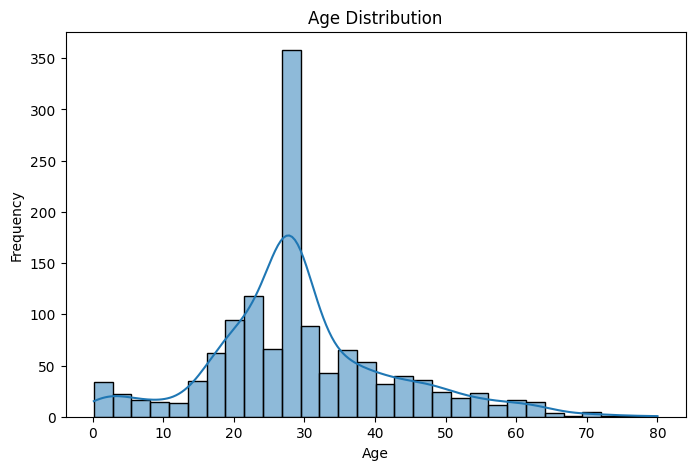

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [41]:
x = df.drop('2urvived',axis=1)
y = df['2urvived']

In [45]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y

)

In [47]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (1047, 8)
x_test: (262, 8)
y_train: (1047,)
y_test: (262,)


In [48]:
categorical_cols = ['Sex', 'Embarked']

numerical_cols = ['Age', 'Fare', 'sibsp', 'Parch', 'Pclass']

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [53]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Fare', 'sibsp',
                                                   'Parch', 'Pclass']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [54]:
y_pred = model.predict(x_test)

In [55]:
print(y_pred[:20])

[1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0]


In [56]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)

Accuracy: 0.7519083969465649
Accuracy %: 75.19083969465649


In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[172  22]
 [ 43  25]]


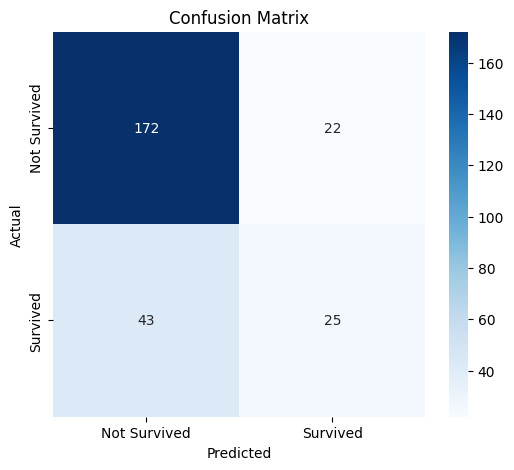

In [58]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       194
           1       0.53      0.37      0.43        68

    accuracy                           0.75       262
   macro avg       0.67      0.63      0.64       262
weighted avg       0.73      0.75      0.74       262



In [61]:
new_passenger = pd.DataFrame({
    'Passengerid': [1309],
    'Age': [25],
    'Fare': [50],
    'Sex': ['male'],
    'sibsp': [0],
    'Parch': [0],
    'Pclass': [2],
    'Embarked': ['S']
})

prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 0
Probability: [0.63416821 0.36583179]


In [62]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

print(coef_df)

             Feature  Coefficient
6         cat__Sex_1     0.966432
8  cat__Embarked_1.0     0.031455
7  cat__Embarked_0.0     0.020906
3         num__Parch    -0.010002
9  cat__Embarked_2.0    -0.052957
1          num__Fare    -0.059948
2         num__sibsp    -0.161938
0           num__Age    -0.420776
4        num__Pclass    -0.738063
5         cat__Sex_0    -0.967028


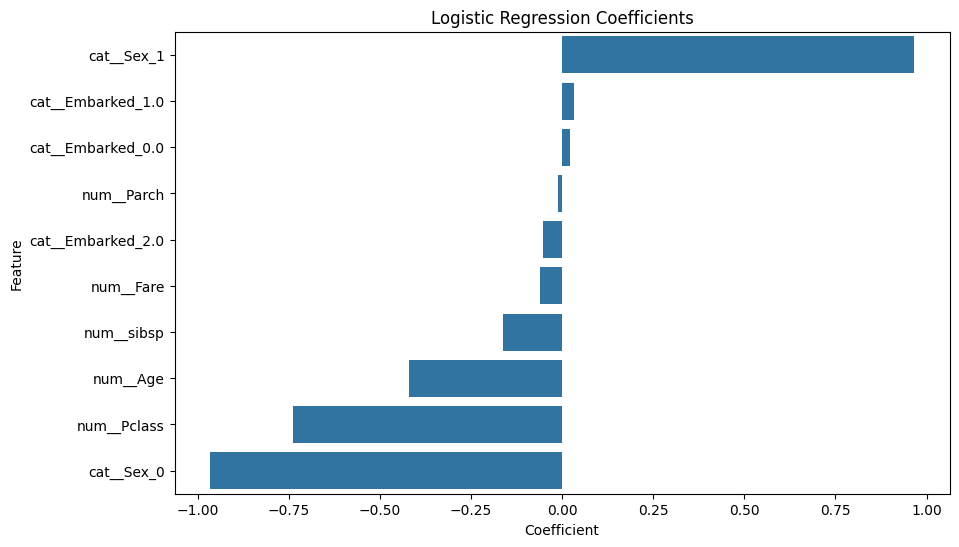

In [63]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)

plt.title('Logistic Regression Coefficients')
plt.show()

In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.79770992 0.83969466 0.79770992 0.69847328 0.7164751 ]
Mean Accuracy: 0.7700125764089967


In [67]:
from sklearn.model_selection import GridSearchCV

params = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best C: {'classifier__C': 1}
Best CV Score: 0.7936750968329915


In [68]:
best_model = grid.best_estimator_

In [70]:
y_pred = best_model.predict(x_test)

from sklearn.metrics import accuracy_score

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.7519083969465649


In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       194
           1       0.53      0.37      0.43        68

    accuracy                           0.75       262
   macro avg       0.67      0.63      0.64       262
weighted avg       0.73      0.75      0.74       262



In [72]:
import joblib

joblib.dump(best_model, 'titanic_logistic_model.pkl')

['titanic_logistic_model.pkl']

In [73]:
model_loaded = joblib.load('titanic_logistic_model.pkl')

In [75]:

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

print(coef_df)

             Feature  Coefficient
6         cat__Sex_1     0.966432
8  cat__Embarked_1.0     0.031455
7  cat__Embarked_0.0     0.020906
3         num__Parch    -0.010002
9  cat__Embarked_2.0    -0.052957
1          num__Fare    -0.059948
2         num__sibsp    -0.161938
0           num__Age    -0.420776
4        num__Pclass    -0.738063
5         cat__Sex_0    -0.967028


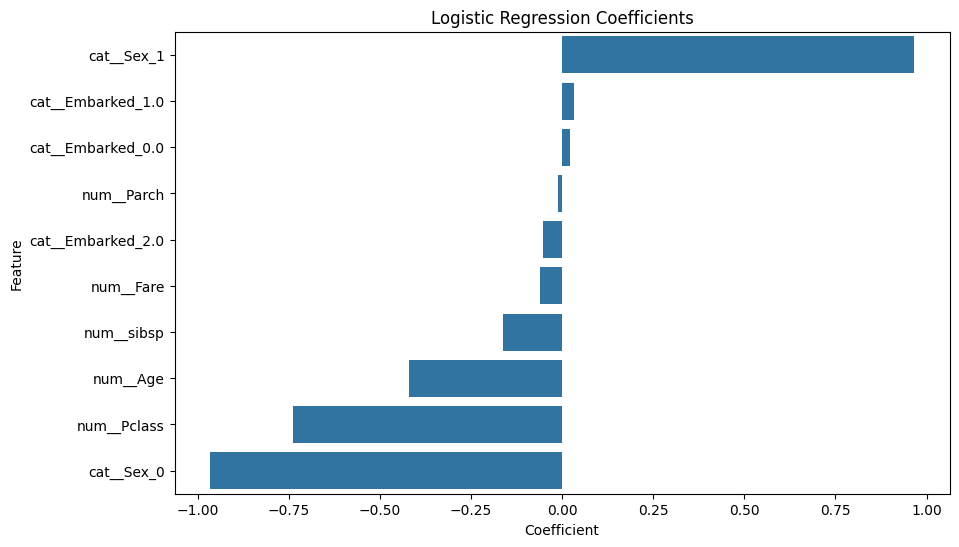

In [76]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)

plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

In [78]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.79770992 0.83969466 0.79770992 0.69847328 0.7164751 ]
Mean CV Accuracy: 0.7700125764089967


In [79]:
import joblib

joblib.dump(model, 'titanic_logistic_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [80]:
from google.colab import files

files.download('titanic_logistic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>